In [2]:

import torch.nn.functional as F
import torch.optim as optim
import numpy as np
from uniformer import uniformer,uniformer_v2
from torchinfo import summary   
import torch
from torch import nn, einsum
from einops import rearrange
from einops.layers.torch import Reduce
from torchvision import transforms
import json
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
from PIL import Image   
import torchvision.models.video as models
from pytorchvideo.models.hub import x3d_xs
import os
from glob import glob
import timm
from torchvision.models.video import mvit_v2_s
device=torch.device("cuda:2" if torch.cuda.is_available() else "cpu")
print(device)

cuda:2


In [46]:
key_list=['물과 비누로 손위생',
 '투약처방과 투약원칙 확인 (손으로 짚어서)',
 '근육주사 약물을 정확한 용량과 방법으로 준비',
 '손소독제로 손위생',
 '대상자의 입원팔찌와 투약카드 대조하여 확인',
 '주사부위 노출 후, 주사부위 선정(삼각근)',
 '물과 비누,알콜젤로 손위생 수행',
 '소독솜으로 닦고, 한손으로 주사바늘 뚜껑 제거',
 '주사바늘 90도로 주사부위 찌름',
 '내관당겨보고, 약물 천천히 주입',
 '삽입각도와 같이 빼고, 주사부위 압박',
 '환의 정리',
 '물과 비누로 손위생 (종료 후)']

params = {
    "image_size": 224,
    "frame_size": 50,
    "num_classes": 2,
    "dim": (64, 128, 256, 512),
    "depth": (3, 4, 8, 3),
    "batch_size":4,
    "mhsa_types": ('l', 'l', 'g', 'g'),
    "epoch": 200,
    "data_path": '../../data/',
    "second": '10sec',
    "class_name": key_list[7],
    "label_path": "../../data/label/check_list/",
    "image_channel": 3
}



params["second"]=f'{params["frame_size"]//5}sec'
params

{'image_size': 224,
 'frame_size': 50,
 'num_classes': 2,
 'dim': (64, 128, 256, 512),
 'depth': (3, 4, 8, 3),
 'batch_size': 4,
 'mhsa_types': ('l', 'l', 'g', 'g'),
 'epoch': 200,
 'data_path': '../../data/',
 'second': '10sec',
 'class_name': '소독솜으로 닦고, 한손으로 주사바늘 뚜껑 제거',
 'label_path': '../../data/label/check_list/',
 'image_channel': 3}

In [ ]:
trans = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])
# 1. 파일 리스트 생성
file_list = [f"D{str(i+1).zfill(3)}" for i in range(200)]
remove_items = ['D151', 'D159', 'D187', 'D080']
filtered_lst = [item for item in file_list if item not in remove_items]

# 2. 영상 데이터 및 라벨 저장 공간
train_images = torch.zeros(len(filtered_lst), params['image_channel'], params['frame_size'],
                           params['image_size'], params['image_size'])  # [N, C, T, H, W]
image_label = []

# 3. 데이터 로딩
for i in tqdm(range(len(filtered_lst))):
    sample_id = filtered_lst[i]
    with open(params['label_path'] + sample_id + '.json', 'r') as f:
        check = json.load(f)

    base_path = params['data_path'] + params["second"] + '/' + params["class_name"] + '/' + sample_id
    image_list_1 = sorted(glob(base_path + '/3/*.png'))

    label = 1 if check['행동'][params["class_name"]] else 0
    image_label.append(label)

    for j in range(params['frame_size']):
        img = Image.open(image_list_1[j]).convert('RGB').resize((params['image_size'], params['image_size']))
        train_images[i, :, j] = trans(img)

# 4. CustomDataset 클래스 수정
class CustomDataset(Dataset):
    def __init__(self, args, video_tensor, labels):
        self.videos = video_tensor  # [N, 3, C, T, H, W]
        self.labels = labels
        self.args = args

    def __getitem__(self, idx):
        video1 = self.videos[idx ]
        label = self.labels[idx]
    
        return video1, label

    def __len__(self):
        return len(self.videos)

# 5. 학습/테스트 분할
split = int(len(train_images) * 0.2)
train_dataset = CustomDataset(params, train_images[split:], F.one_hot(torch.tensor(image_label[split:]), num_classes=params['num_classes']).float())
test_dataset  = CustomDataset(params, train_images[:split], F.one_hot(torch.tensor(image_label[:split]), num_classes=params['num_classes']).float())

# 6. DataLoader 구성
train_dataloader = DataLoader(train_dataset, batch_size=params['batch_size'], shuffle=True, drop_last=True)
test_dataloader  = DataLoader(test_dataset, batch_size=params['batch_size'], shuffle=False, drop_last=True)

100%|██████████| 196/196 [02:33<00:00,  1.28it/s]


In [53]:
class MultiMVitV2S(nn.Module):
    def __init__(self, num_classes=2, pretrained=True):
        super().__init__()

        # 세 개의 MViTv2-S 모델을 생성 (출력 차원은 768)
        self.backbone1 = mvit_v2_s(
            weights=None,  # 또는 weights=... 사전 학습된 거 쓰되 interpolation
            spatial_size=(params['image_size'], params['image_size']),
            temporal_size=params['frame_size']
        )

        # 각 모델의 마지막 fc 제거 후 feature 추출
        self.backbone1.head = nn.Identity()


        # 세 feature를 concat 후 최종 분류
        self.classifier = nn.Sequential(
            nn.Linear(768 , 512),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(512, num_classes)
        )

    def forward(self, video1):
        # 입력: [B, C, T, H, W]
        feat1 = self.backbone1(video1)  # [B, 768]

        return self.classifier(feat1)  # [B, num_classes]
    
# model = MultiMVitV2S(
#     num_classes=params['num_classes']
# ).to(device)

# pretrained 모델 로드
model = x3d_xs(pretrained=True, progress=True).to(device)

# in_features 구하기
in_features = model.blocks[-1].proj.in_features

# Dropout + Linear 로 head 교체
model.blocks[-1].proj = nn.Sequential(
    nn.Dropout(p=0.5),              # 드롭아웃 비율 50%
    nn.Linear(in_features, 2)       # 2-class 출력
).to(device)

video_size = (
    params['batch_size'],       # B
    params['image_channel'],    # C = 3
    params["frame_size"],                         # T = 16 (MViT 기준)
    params['image_size'],       # H
    params['image_size']        # W
)

# Optimizer & Loss 정의
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)
criterion = nn.CrossEntropyLoss()

# 디렉토리 생성 함수
def create_dir(path):
    if not os.path.exists(path):
        os.makedirs(path)

# 모델 구조 출력
summary(
    model,
    input_size=[video_size],  # 1개 비디오 입력
    device=str(device)
)


Layer (type:depth-idx)                                       Output Shape              Param #
Net                                                          [4, 2]                    --
├─ModuleList: 1-1                                            --                        --
│    └─ResNetBasicStem: 2-1                                  [4, 24, 50, 112, 112]     --
│    │    └─Conv2plus1d: 3-1                                 [4, 24, 50, 112, 112]     768
│    │    └─BatchNorm3d: 3-2                                 [4, 24, 50, 112, 112]     48
│    │    └─ReLU: 3-3                                        [4, 24, 50, 112, 112]     --
│    └─ResStage: 2-2                                         [4, 24, 50, 56, 56]       --
│    │    └─ModuleList: 3-4                                  --                        15,370
│    └─ResStage: 2-3                                         [4, 48, 50, 28, 28]       --
│    │    └─ModuleList: 3-5                                  --                        73,

In [54]:
best_val_loss = float('inf')

for epc in range(params['epoch']):
    model.train()
    total_loss = 0
    total_correct = 0
    total_samples = 0
    steps = 0

    with tqdm(train_dataloader, dynamic_ncols=True) as tqdmDataLoader:
        for video1, lab in tqdmDataLoader:
            optimizer.zero_grad()

            # 데이터 준비
            video1 = video1.to(device)
 
            lab = lab.to(device)

            # 모델 forward
            output = model(video1) # (B, num_classes)
            loss = criterion(output, lab.argmax(dim=1))  # CrossEntropyLoss expects class index

            # 역전파
            loss.backward()
            optimizer.step()

            # 통계
            total_loss += loss.item()
            steps += 1

            # Accuracy 계산
            preds = output.argmax(dim=1)
            targets = lab.argmax(dim=1)
            total_correct += (preds == targets).sum().item()
            total_samples += lab.size(0)

            tqdmDataLoader.set_postfix(
                ordered_dict={
                    "epoch": epc + 1,
                    "loss": total_loss / steps,
                    "acc": f"{100 * total_correct / total_samples:.2f}%",
                    "batch": lab.size(0),
                    "LR": optimizer.param_groups[0]["lr"]
                }
            )

    # ======== Validation ========
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    val_steps = 0

    with torch.no_grad():
        with tqdm(test_dataloader, desc=f"[Valid] Epoch {epc+1}", dynamic_ncols=True) as tqdmVal:
            for video1,lab in tqdmVal:
                video1 = video1.to(device)
         
                lab = lab.to(device)

                output = model(video1)
                loss = criterion(output, lab.argmax(dim=1))

                val_loss += loss.item()
                val_steps += 1
                preds = output.argmax(dim=1)
                targets = lab.argmax(dim=1)
                val_correct += (preds == targets).sum().item()
                val_total += lab.size(0)

                tqdmVal.set_postfix(
                    val_loss=f"{val_loss / val_steps:.4f}",
                    val_acc=f"{100 * val_correct / val_total:.2f}%"
                )

    # ======== 모델 저장 ========
    avg_val_loss = val_loss / val_steps
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        c1 = params["class_name"]
        c2 = params["second"]
        create_dir(f"../../model/{c1}/")
        torch.save(model.state_dict(), f"../../model/{c1}/best_model_{c2}.pt")
        print(f"✅ Model saved at epoch {epc+1} with validation loss {best_val_loss:.4f}")


[Valid] Epoch 1: 100%|██████████| 9/9 [00:00<00:00, 11.12it/s, val_acc=38.89%, val_loss=0.7903]


✅ Model saved at epoch 1 with validation loss 0.7903


[Valid] Epoch 3: 100%|██████████| 9/9 [00:00<00:00, 12.72it/s, val_acc=47.22%, val_loss=0.7236]


✅ Model saved at epoch 3 with validation loss 0.7236


[Valid] Epoch 4: 100%|██████████| 9/9 [00:00<00:00, 10.82it/s, val_acc=55.56%, val_loss=0.6950]


...

✅ Model saved at epoch 8 with validation loss 0.6087


[Valid] Epoch 14: 100%|██████████| 9/9 [00:00<00:00, 10.81it/s, val_acc=80.56%, val_loss=0.5347]


✅ Model saved at epoch 14 with validation loss 0.5347


 56%|█████▋    | 22/39 [00:05<00:04,  4.02it/s, epoch=18, loss=0.349, acc=96.59%, batch=4, LR=0.001]


KeyboardInterrupt: 

In [50]:
for name, param in model.named_parameters():
    if param.grad is not None:
        print(name, param.grad.abs().mean())

blocks.0.conv.conv_t.weight tensor(3.8902e-06, device='cuda:2')
blocks.0.conv.conv_xy.weight tensor(2.2407e-06, device='cuda:2')
blocks.0.norm.weight tensor(3.3969e-06, device='cuda:2')
blocks.0.norm.bias tensor(2.3951e-06, device='cuda:2')
blocks.1.res_blocks.0.branch1_conv.weight tensor(2.2107e-06, device='cuda:2')
blocks.1.res_blocks.0.branch2.conv_a.weight tensor(1.8337e-06, device='cuda:2')
blocks.1.res_blocks.0.branch2.norm_a.weight tensor(6.2628e-07, device='cuda:2')
blocks.1.res_blocks.0.branch2.norm_a.bias tensor(8.3149e-07, device='cuda:2')
blocks.1.res_blocks.0.branch2.conv_b.weight tensor(2.0610e-06, device='cuda:2')
blocks.1.res_blocks.0.branch2.norm_b.0.weight tensor(8.2988e-07, device='cuda:2')
blocks.1.res_blocks.0.branch2.norm_b.0.bias tensor(6.0393e-07, device='cuda:2')
blocks.1.res_blocks.0.branch2.norm_b.1.block.0.weight tensor(6.9891e-07, device='cuda:2')
blocks.1.res_blocks.0.branch2.norm_b.1.block.0.bias tensor(4.4427e-07, device='cuda:2')
blocks.1.res_blocks.0.b

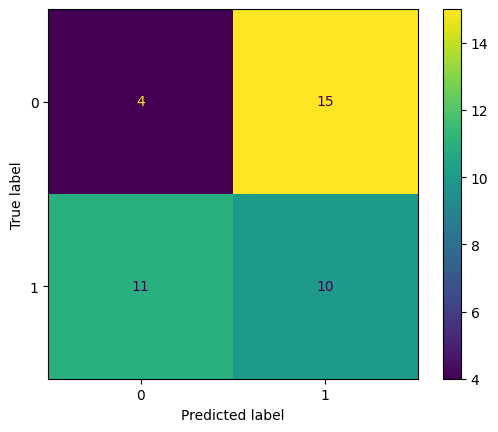

In [104]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

all_preds = []
all_labels = []
model.eval()
with torch.no_grad():
    for video, label in test_dataloader:
        output = model(video.to(device))
        preds = output.argmax(dim=1).cpu().numpy()
        targets = label.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(targets)

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()